# Evaluación de Modelos No Paramétricos — Consumo Metro Medellín

**Objetivo:** entrenar LightGBM, XGBoost y Random Forest para predecir el consumo eléctrico diario de un mes completo a partir del corte del mes anterior.

**Meses de test evaluados:** Oct-2024, Nov-2024, Dic-2024, Ene-2025  
**Consideración clave:** para el día N del mes test solo se usan lags ≥ N (los lags menores no están disponibles en producción desde el punto de corte).


## 1. Imports y configuración

In [ ]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'figure.facecolor': 'white'})

try:
    import lightgbm as lgb
    HAS_LGB = True
    print("✓ LightGBM disponible:", lgb.__version__)
except ImportError:
    HAS_LGB = False
    print("✗ LightGBM no instalado — pip install lightgbm")

try:
    import xgboost as xgb
    HAS_XGB = True
    print("✓ XGBoost disponible:", xgb.__version__)
except ImportError:
    HAS_XGB = False
    print("✗ XGBoost no instalado — pip install xgboost")

print("✓ scikit-learn, numpy, pandas, matplotlib listos")


✓ LightGBM disponible: 4.6.0
✓ XGBoost disponible: 3.2.0
✓ scikit-learn, numpy, pandas, matplotlib listos


## 2. Configuración global

In [ ]:
# ─── AJUSTA AQUÍ ─────────────────────────────────────────────────────────────
CSV_PATH    = 'features_mes_completo.csv'   # ruta al dataset
TEST_MONTHS = ['2024-10', '2024-11', '2024-12', '2025-01']  # meses a evaluar
SEED        = 42
# ─────────────────────────────────────────────────────────────────────────────

# Paleta de colores por modelo (consistente en todas las gráficas)
COLORS = {
    'LightGBM'    : '#1976D2',   # azul
    'XGBoost'     : '#E64A19',   # naranja-rojo
    'RandomForest': '#388E3C',   # verde
}

# Modelos activos (se excluyen si la librería no está instalada)
MODELS = []
if HAS_LGB: MODELS.append('LightGBM')
if HAS_XGB: MODELS.append('XGBoost')
MODELS.append('RandomForest')

print(f"Modelos a evaluar: {MODELS}")
print(f"Meses de test    : {TEST_MONTHS}")


Modelos a evaluar: ['LightGBM', 'XGBoost', 'RandomForest']
Meses de test    : ['2024-10', '2024-11', '2024-12', '2025-01']


## 3. Carga y exploración rápida del dataset

Shape           : (2852, 90)
Rango de fechas : 2018-03-12 → 2025-12-31
Total columnas  : 90

Sin valores nulos en el dataset.

--- Estadísticas de Consumo ---
count     2852.00
mean     69211.58
std      13227.50
min      19741.34
25%      66415.94
50%      75104.35
75%      78048.68
max      88671.02
Name: Consumo, dtype: float64


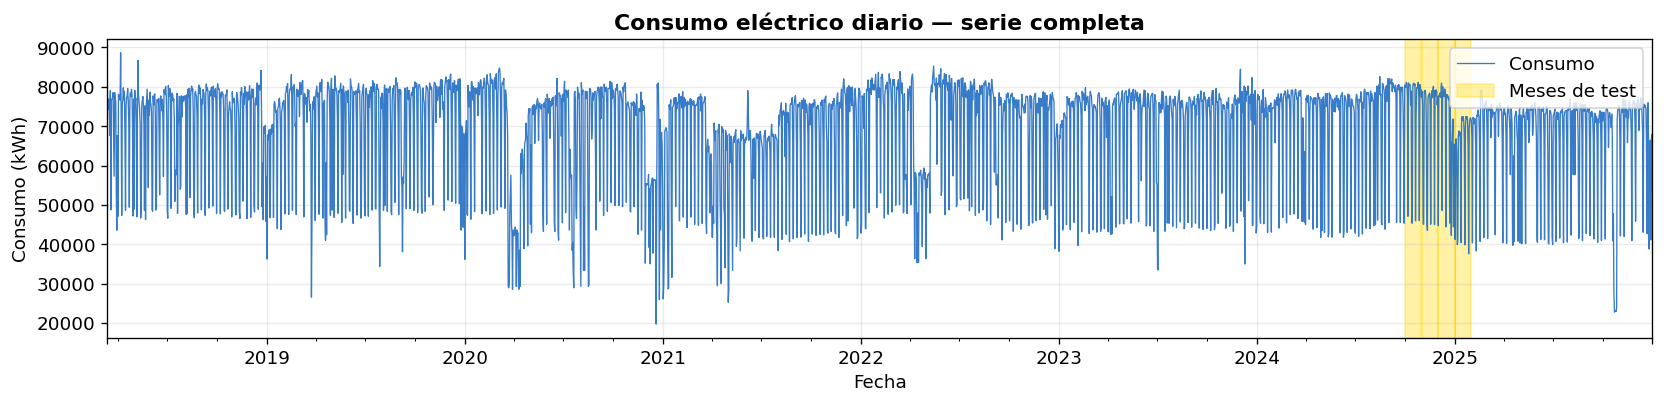

In [ ]:
df = pd.read_csv(CSV_PATH, index_col='Fecha', parse_dates=True)
df.index = pd.to_datetime(df.index)
df.sort_index(inplace=True)

print(f"Shape           : {df.shape}")
print(f"Rango de fechas : {df.index.min().date()} → {df.index.max().date()}")
print(f"Total columnas  : {len(df.columns)}")

# Nulos
nulos = df.isnull().sum()
nulos_cols = nulos[nulos > 0]
if len(nulos_cols):
    print(f"\nColumnas con nulos:\n{nulos_cols}")
else:
    print("\nSin valores nulos en el dataset.")

# Target
print(f"\n--- Estadísticas de Consumo ---")
print(df['Consumo'].describe().round(2))

# Plot general del target
fig, ax = plt.subplots(figsize=(14, 3.5))
df['Consumo'].plot(ax=ax, lw=0.8, color='#1565C0', alpha=0.85)
ax.set_title('Consumo eléctrico diario — serie completa', fontweight='bold')
ax.set_ylabel('Consumo (kWh)')
ax.set_xlabel('Fecha')
ax.grid(True, alpha=0.25)
for mes in TEST_MONTHS:
    ax.axvspan(pd.Timestamp(f'{mes}-01'),
               pd.Timestamp(f'{mes}-01') + pd.offsets.MonthEnd(1),
               color='gold', alpha=0.35, label=mes if mes == TEST_MONTHS[0] else '')
ax.legend(['Consumo', 'Meses de test'], loc='upper right')
plt.tight_layout()
plt.savefig('serie_completa.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Definición de feature sets por tipo de modelo

In [ ]:
all_cols = df.columns.tolist()

# ── Variables de calendario (ordinales) ──────────────────────────────────────
CALENDAR_ORDINAL = [
    'dia_semana', 'mes', 'año', 'semana_año',
    'es_fin_semana', 'es_festivo', 'dia_antes_festivo',
    'dia_despues_festivo', 'semana_navidad',
    'covid_cuarentena', 'es_mantenimiento'
]
CALENDAR_ORDINAL = [c for c in CALENDAR_ORDINAL if c in all_cols]

# ── Lags del target (detección dinámica desde el CSV) ────────────────────────
_pat_lag = re.compile(r'^lag_(\d+)$')

def get_lag_cols(columns):
    """Retorna columnas de lag ordenadas por valor numérico."""
    lags = [(int(_pat_lag.match(c).group(1)), c)
            for c in columns if _pat_lag.match(c)]
    return [c for _, c in sorted(lags)]

LAG_COLS = get_lag_cols(all_cols)
LAG_NUMS = {c: int(_pat_lag.match(c).group(1)) for c in LAG_COLS}

# ── Estadísticas rolling ─────────────────────────────────────────────────────
ROLL_COLS = sorted([
    c for c in all_cols
    if any(c.startswith(p) for p in ['media_roll', 'std_roll', 'mediana_roll'])
])

# ── Codificación cíclica (solo modelos lineales/redes — NO para árboles) ─────
CYCLIC_COLS = [c for c in ['dow_sin', 'dow_cos', 'mes_sin', 'mes_cos']
               if c in all_cols]

# ── Feature set final para modelos de árbol ───────────────────────────────────
#    Ordinales ✓ | Lags ✓ | Rolling ✓ | Cíclicas ✗
FEATURES_TREE = CALENDAR_ORDINAL + LAG_COLS + ROLL_COLS

print("=" * 55)
print("Feature set para LightGBM / XGBoost / RandomForest")
print("=" * 55)
print(f"  Calendario (ordinal) : {len(CALENDAR_ORDINAL):>3}  {CALENDAR_ORDINAL}")
print(f"  Lags del target      : {len(LAG_COLS):>3}  lag_1 … lag_{max(LAG_NUMS.values())}")
print(f"  Rolling stats        : {len(ROLL_COLS):>3}  {ROLL_COLS}")
print(f"  TOTAL features       : {len(FEATURES_TREE):>3}")
print()
print(f"Cíclicas disponibles (no usadas para árboles): {CYCLIC_COLS}")

# Verificar que todas las features existen en el CSV
missing = [f for f in FEATURES_TREE if f not in all_cols]
if missing:
    print(f"\n⚠ Features no encontradas en el CSV: {missing}")
else:
    print("\n✓ Todas las features encontradas en el CSV.")


Feature set para LightGBM / XGBoost / RandomForest
  Calendario (ordinal) :  11  ['dia_semana', 'mes', 'año', 'semana_año', 'es_fin_semana', 'es_festivo', 'dia_antes_festivo', 'dia_despues_festivo', 'semana_navidad', 'covid_cuarentena', 'es_mantenimiento']
  Lags del target      :  62  lag_1 … lag_70
  Rolling stats        :  12  ['media_roll_14', 'media_roll_28', 'media_roll_60', 'media_roll_7', 'mediana_roll_14', 'mediana_roll_28', 'mediana_roll_60', 'mediana_roll_7', 'std_roll_14', 'std_roll_28', 'std_roll_60', 'std_roll_7']
  TOTAL features       :  85

Cíclicas disponibles (no usadas para árboles): ['dow_sin', 'dow_cos', 'mes_sin', 'mes_cos']

✓ Todas las features encontradas en el CSV.


## 5. Funciones auxiliares

### 5.1 Máscara de lags inválidos por horizonte

**Principio:** cuando predecimos el día *N* del mes test desde el corte (último día del mes anterior), solo los lags ≥ N están disponibles. Los lags menores corresponden a días que aún no han ocurrido y deben enmascararse con `NaN`.

```
Ejemplo:
  Día 20 del mes test → solo lag_20, lag_21, …, lag_60, lag_63, lag_70 son válidos
  lag_1 … lag_19 → NaN
```


In [ ]:
def mask_invalid_lags(X_test: pd.DataFrame) -> pd.DataFrame:
    """
    Para cada fila del mes test (día N del mes), anula los lag_k con k < N
    porque no estarían disponibles en producción desde el punto de corte.

    Los lags semanales (lag_56, lag_63, lag_70) son siempre ≥ 31
    y por tanto siempre válidos para cualquier día del mes test.

    Parámetros
    ----------
    X_test : DataFrame con índice DatetimeIndex (un mes completo).

    Retorna
    -------
    DataFrame con los mismos datos pero con NaN donde corresponda.
    """
    X_masked = X_test.copy()

    # Identificar solo las columnas de lag en X_test
    lag_info = {c: int(_pat_lag.match(c).group(1))
                for c in X_test.columns if _pat_lag.match(c)}

    if not lag_info:
        return X_masked

    for date in X_masked.index:
        N = date.day  # día del mes: 1-indexado
        for col, k in lag_info.items():
            if k < N:
                X_masked.loc[date, col] = np.nan

    return X_masked


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """Calcula MAE, RMSE, MAPE (%) y R²."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    r2   = r2_score(y_true, y_pred)
    return {
        'MAE'     : round(mae, 2),
        'RMSE'    : round(rmse, 2),
        'MAPE (%)': round(mape, 4),
        'R²'      : round(r2, 4),
    }


def train_and_predict(model_name, X_train, y_train, X_test_masked, X_train_for_imp=None):
    """
    Entrena el modelo indicado y retorna (predicciones, modelo).

    LightGBM y XGBoost manejan NaN nativamente.
    RandomForest requiere imputación previa (SimpleImputer con la media de train).
    """
    if model_name == 'LightGBM':
        model = lgb.LGBMRegressor(
            n_estimators=1200,
            learning_rate=0.04,
            num_leaves=63,
            min_child_samples=15,
            subsample=0.85,
            colsample_bytree=0.75,
            reg_alpha=0.1,
            reg_lambda=0.5,
            random_state=SEED,
            verbose=-1,
        )
        model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train)],
            callbacks=[lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(period=-1)],
        )
        preds = model.predict(X_test_masked)

    elif model_name == 'XGBoost':
        model = xgb.XGBRegressor(
            n_estimators=1200,
            learning_rate=0.04,
            max_depth=6,
            subsample=0.85,
            colsample_bytree=0.75,
            reg_alpha=0.1,
            reg_lambda=1.0,
            tree_method='hist',   # soporta NaN nativamente
            random_state=SEED,
            verbosity=0,
        )
        model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train)],
            verbose=False,
        )
        preds = model.predict(X_test_masked)

    elif model_name == 'RandomForest':
        # RF (sklearn) no maneja NaN → imputar con la media de entrenamiento
        imputer = SimpleImputer(strategy='mean')
        X_train_imp = imputer.fit_transform(X_train)
        X_test_imp  = imputer.transform(X_test_masked)

        model = RandomForestRegressor(
            n_estimators=600,
            max_depth=None,
            min_samples_leaf=4,
            max_features='sqrt',
            n_jobs=-1,
            random_state=SEED,
        )
        model.fit(X_train_imp, y_train)
        preds = model.predict(X_test_imp)
        # Guardar el imputer dentro del modelo para uso posterior
        model._imputer = imputer

    return preds, model


# ── Función de reporte rápido ─────────────────────────────────────────────────
def print_metrics(model_name, metrics):
    print(f"  [{model_name:13s}] "
          f"MAE={metrics['MAE']:>10,.0f}  "
          f"RMSE={metrics['RMSE']:>10,.0f}  "
          f"MAPE={metrics['MAPE (%)']:>6.2f}%  "
          f"R²={metrics['R²']:.4f}")

print("✓ Funciones auxiliares definidas.")


✓ Funciones auxiliares definidas.


## 6. Loop de evaluación principal

Para cada mes de test:
1. Se define el **corte**: todos los datos hasta el último día del mes anterior.
2. Se construye `X_test_masked` aplicando la máscara de lags inválidos.
3. Se entrenan los tres modelos y se registran predicciones y métricas.


In [ ]:
results = {}   # results[mes][modelo] = {preds, real, dates, metrics, model}

for mes_test in TEST_MONTHS:
    print(f"\n{'='*65}")
    print(f"  MES TEST: {mes_test}")
    print(f"{'='*65}")

    # ── Split ────────────────────────────────────────────────────────────────
    cutoff_start = pd.Timestamp(f'{mes_test}-01')
    cutoff_end   = cutoff_start + pd.offsets.MonthEnd(1)

    train = df[df.index <  cutoff_start]
    test  = df[(df.index >= cutoff_start) & (df.index <= cutoff_end)]

    print(f"  Train : {train.index.min().date()} → {train.index.max().date()} "
          f"({len(train)} días)")
    print(f"  Test  : {test.index.min().date()}  → {test.index.max().date()} "
          f"({len(test)} días)")

    # ── Features ─────────────────────────────────────────────────────────────
    X_train = train[FEATURES_TREE]
    y_train = train['Consumo']

    X_test_raw    = test[FEATURES_TREE]
    X_test_masked = mask_invalid_lags(X_test_raw)
    y_test        = test['Consumo']

    # Diagnóstico de la máscara
    nans_added = (X_test_masked.isnull().sum().sum()
                  - X_test_raw.isnull().sum().sum())
    print(f"  NaN introducidos por máscara de lags: {nans_added}")

    # ── Entrenamiento y predicción ───────────────────────────────────────────
    results[mes_test] = {}

    for model_name in MODELS:
        preds, model = train_and_predict(
            model_name, X_train, y_train, X_test_masked
        )
        metrics = compute_metrics(y_test.values, preds)

        results[mes_test][model_name] = {
            'preds'  : preds,
            'real'   : y_test.values,
            'dates'  : y_test.index,
            'metrics': metrics,
            'model'  : model,
        }
        print_metrics(model_name, metrics)

print("\n✓ Evaluación completa.")



  MES TEST: 2024-10
  Train : 2018-03-12 → 2024-09-30 (2395 días)
  Test  : 2024-10-01  → 2024-10-31 (31 días)
  NaN introducidos por máscara de lags: 465
  [LightGBM     ] MAE=    12,325  RMSE=    13,749  MAPE= 16.43%  R²=-0.2264
  [XGBoost      ] MAE=     3,336  RMSE=     5,443  MAPE=  5.85%  R²=0.8078
  [RandomForest ] MAE=     6,550  RMSE=     7,088  MAPE=  9.34%  R²=0.6740

  MES TEST: 2024-11
  Train : 2018-03-12 → 2024-10-31 (2426 días)
  Test  : 2024-11-01  → 2024-11-30 (30 días)
  NaN introducidos por máscara de lags: 435
  [LightGBM     ] MAE=    10,307  RMSE=    11,823  MAPE= 14.47%  R²=0.2030
  [XGBoost      ] MAE=     3,051  RMSE=     4,238  MAPE=  5.48%  R²=0.8976
  [RandomForest ] MAE=     5,708  RMSE=     6,535  MAPE=  9.08%  R²=0.7565

  MES TEST: 2024-12
  Train : 2018-03-12 → 2024-11-30 (2456 días)
  Test  : 2024-12-01  → 2024-12-31 (31 días)
  NaN introducidos por máscara de lags: 465
  [LightGBM     ] MAE=     9,174  RMSE=    11,526  MAPE= 13.17%  R²=0.2085
  [XGB

## 7. Predicción vs Real — por mes

Cada panel muestra el consumo real y las predicciones de los tres modelos para un mes completo.  
La leyenda incluye el MAPE (%) de cada modelo.


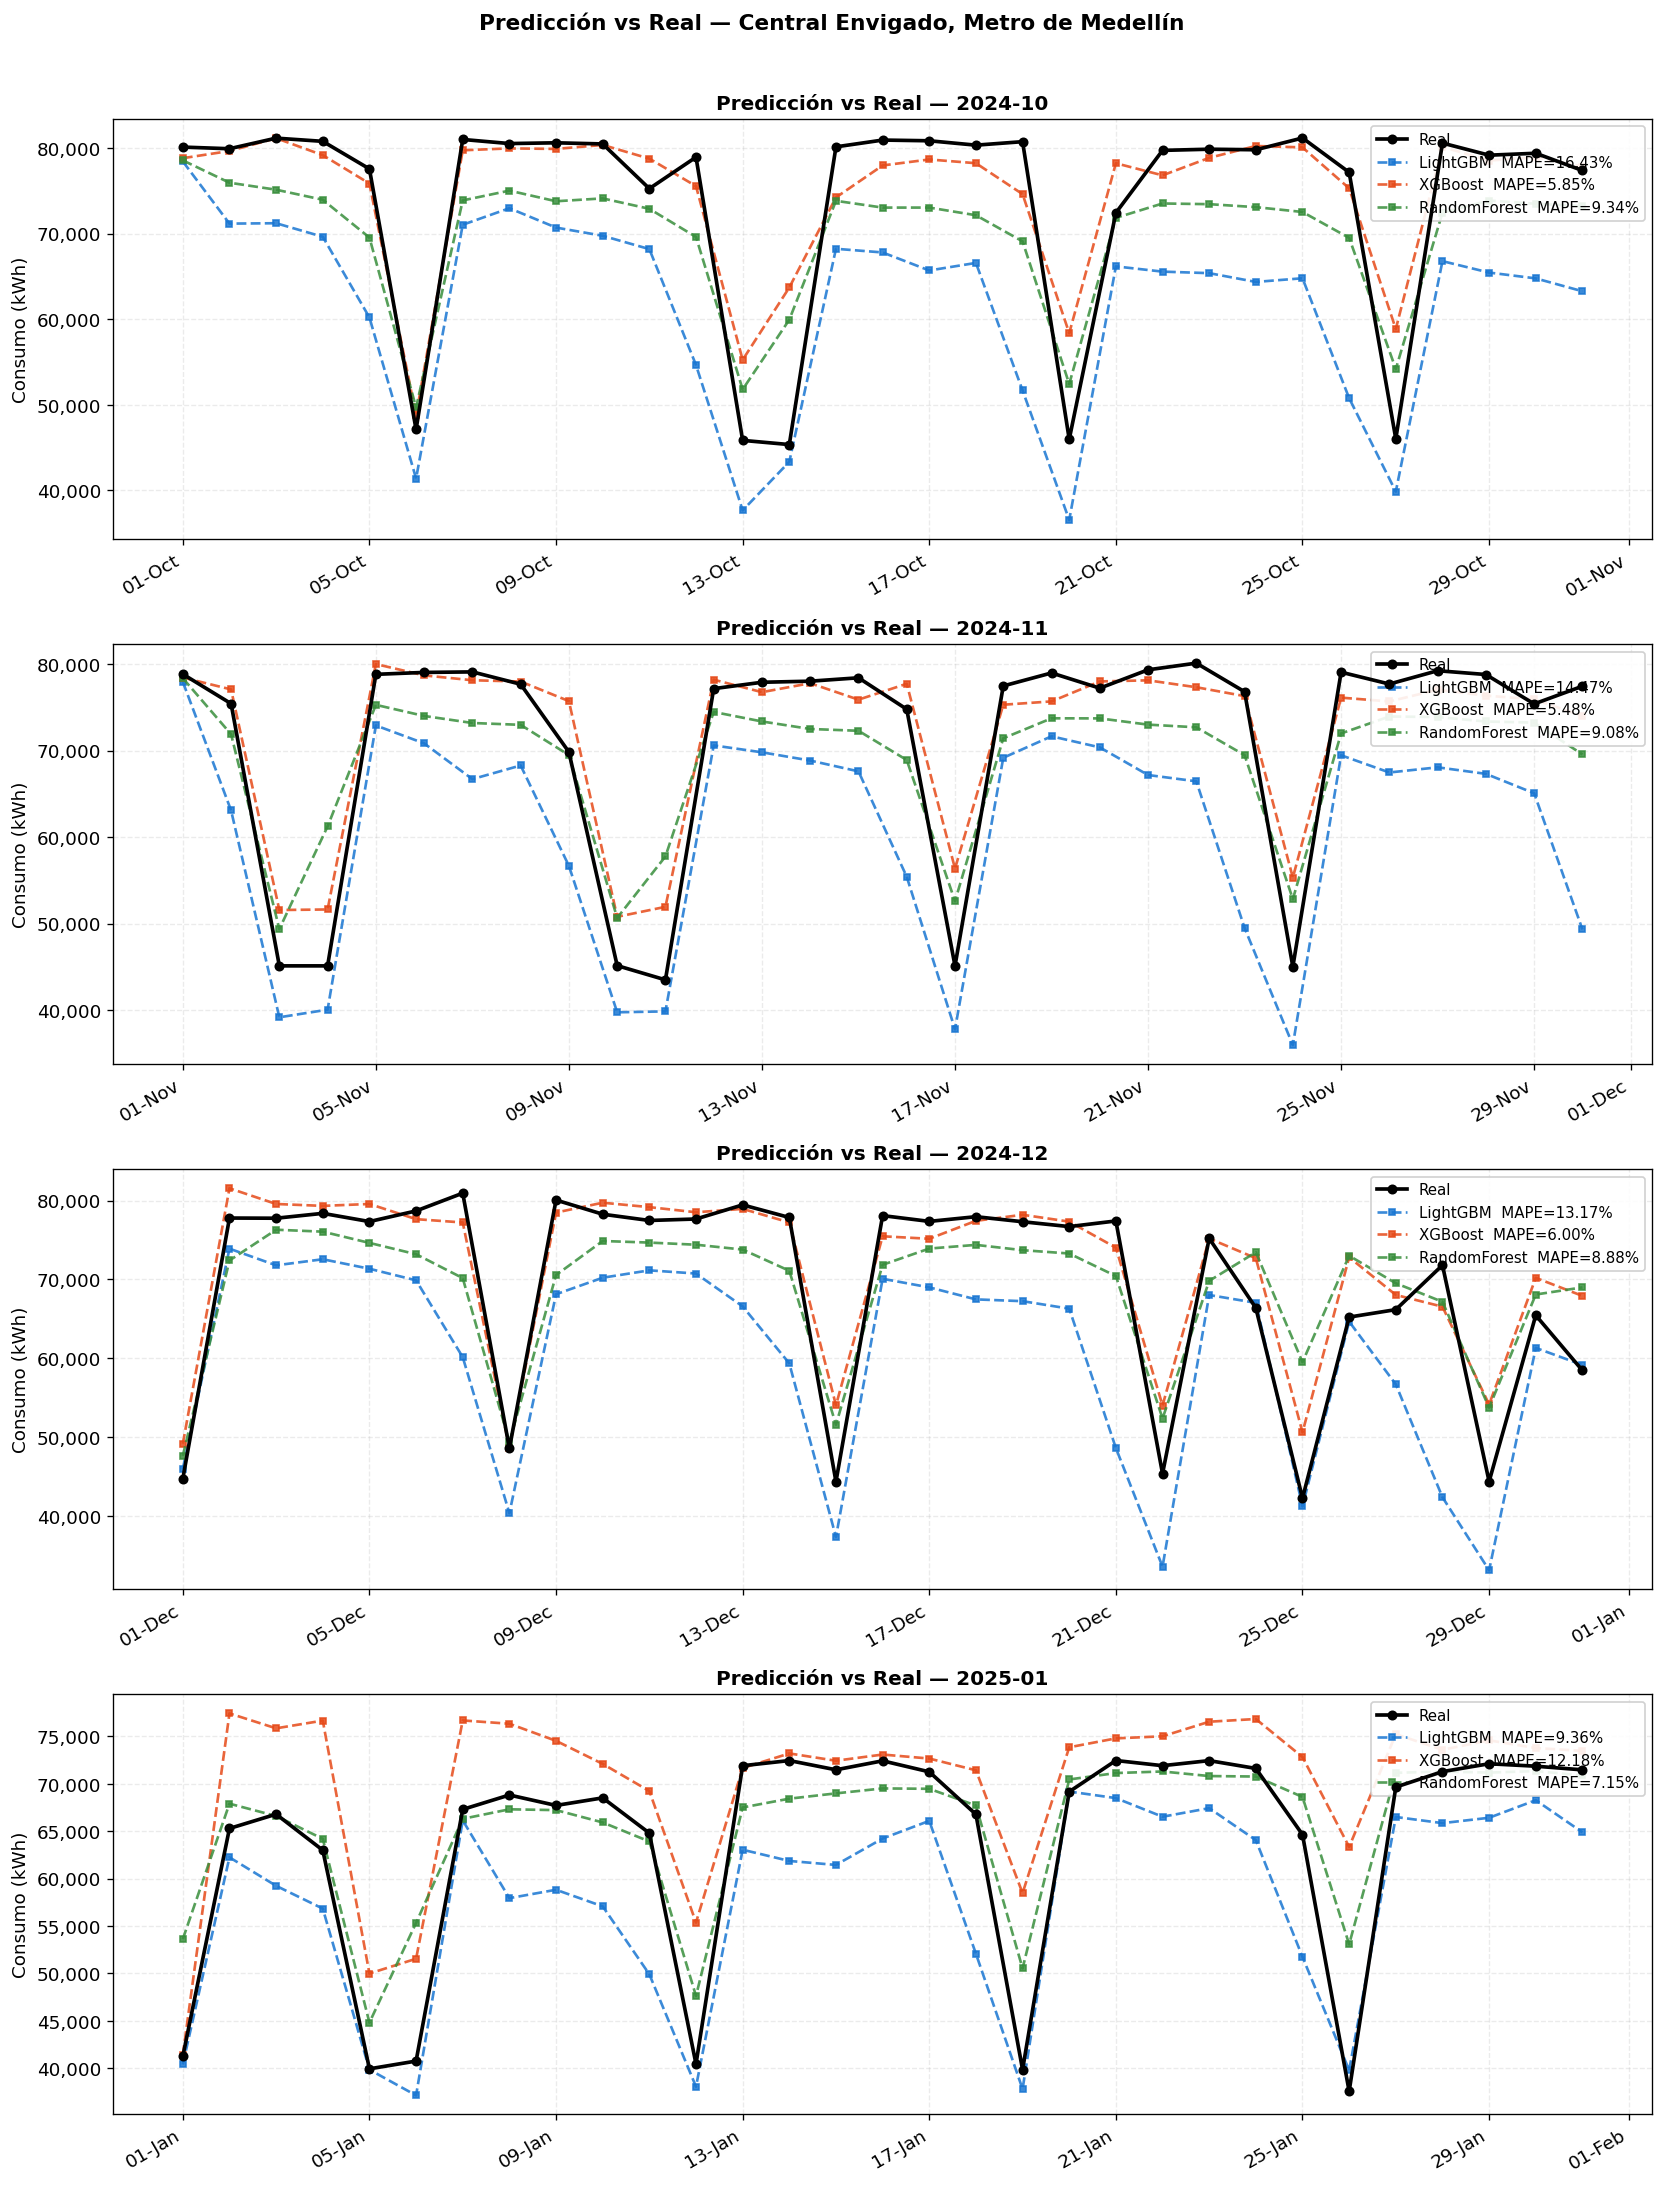

Guardado: pred_vs_real.png


In [ ]:
n_mes = len(TEST_MONTHS)
fig, axes = plt.subplots(n_mes, 1, figsize=(14, 4.5 * n_mes), sharex=False)
if n_mes == 1:
    axes = [axes]

for ax, mes in zip(axes, TEST_MONTHS):
    res = results[mes]
    dates = res[MODELS[0]]['dates']
    real  = res[MODELS[0]]['real']

    ax.plot(dates, real, 'k-o', lw=2.2, ms=5, label='Real', zorder=6)

    for model_name in MODELS:
        p    = res[model_name]['preds']
        mape = res[model_name]['metrics']['MAPE (%)']
        ax.plot(dates, p,
                linestyle='--', marker='s', ms=4, lw=1.6,
                color=COLORS[model_name], alpha=0.85,
                label=f"{model_name}  MAPE={mape:.2f}%", zorder=5)

    ax.set_title(f'Predicción vs Real — {mes}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Consumo (kWh)')
    ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
    ax.grid(True, alpha=0.25, linestyle='--')
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d-%b'))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Predicción vs Real — Central Envigado, Metro de Medellín',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('pred_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: pred_vs_real.png")


## 8. Degradación del error con el horizonte

Muestra el error absoluto día a día dentro del mes. Permite ver si el modelo se deteriora significativamente para horizontes lejanos (días 20-30), donde los lags cortos ya no estaban disponibles y el modelo debe apoyarse en lags largos y variables de calendario.

La línea sólida es la media móvil (ventana 5 días) del error absoluto.


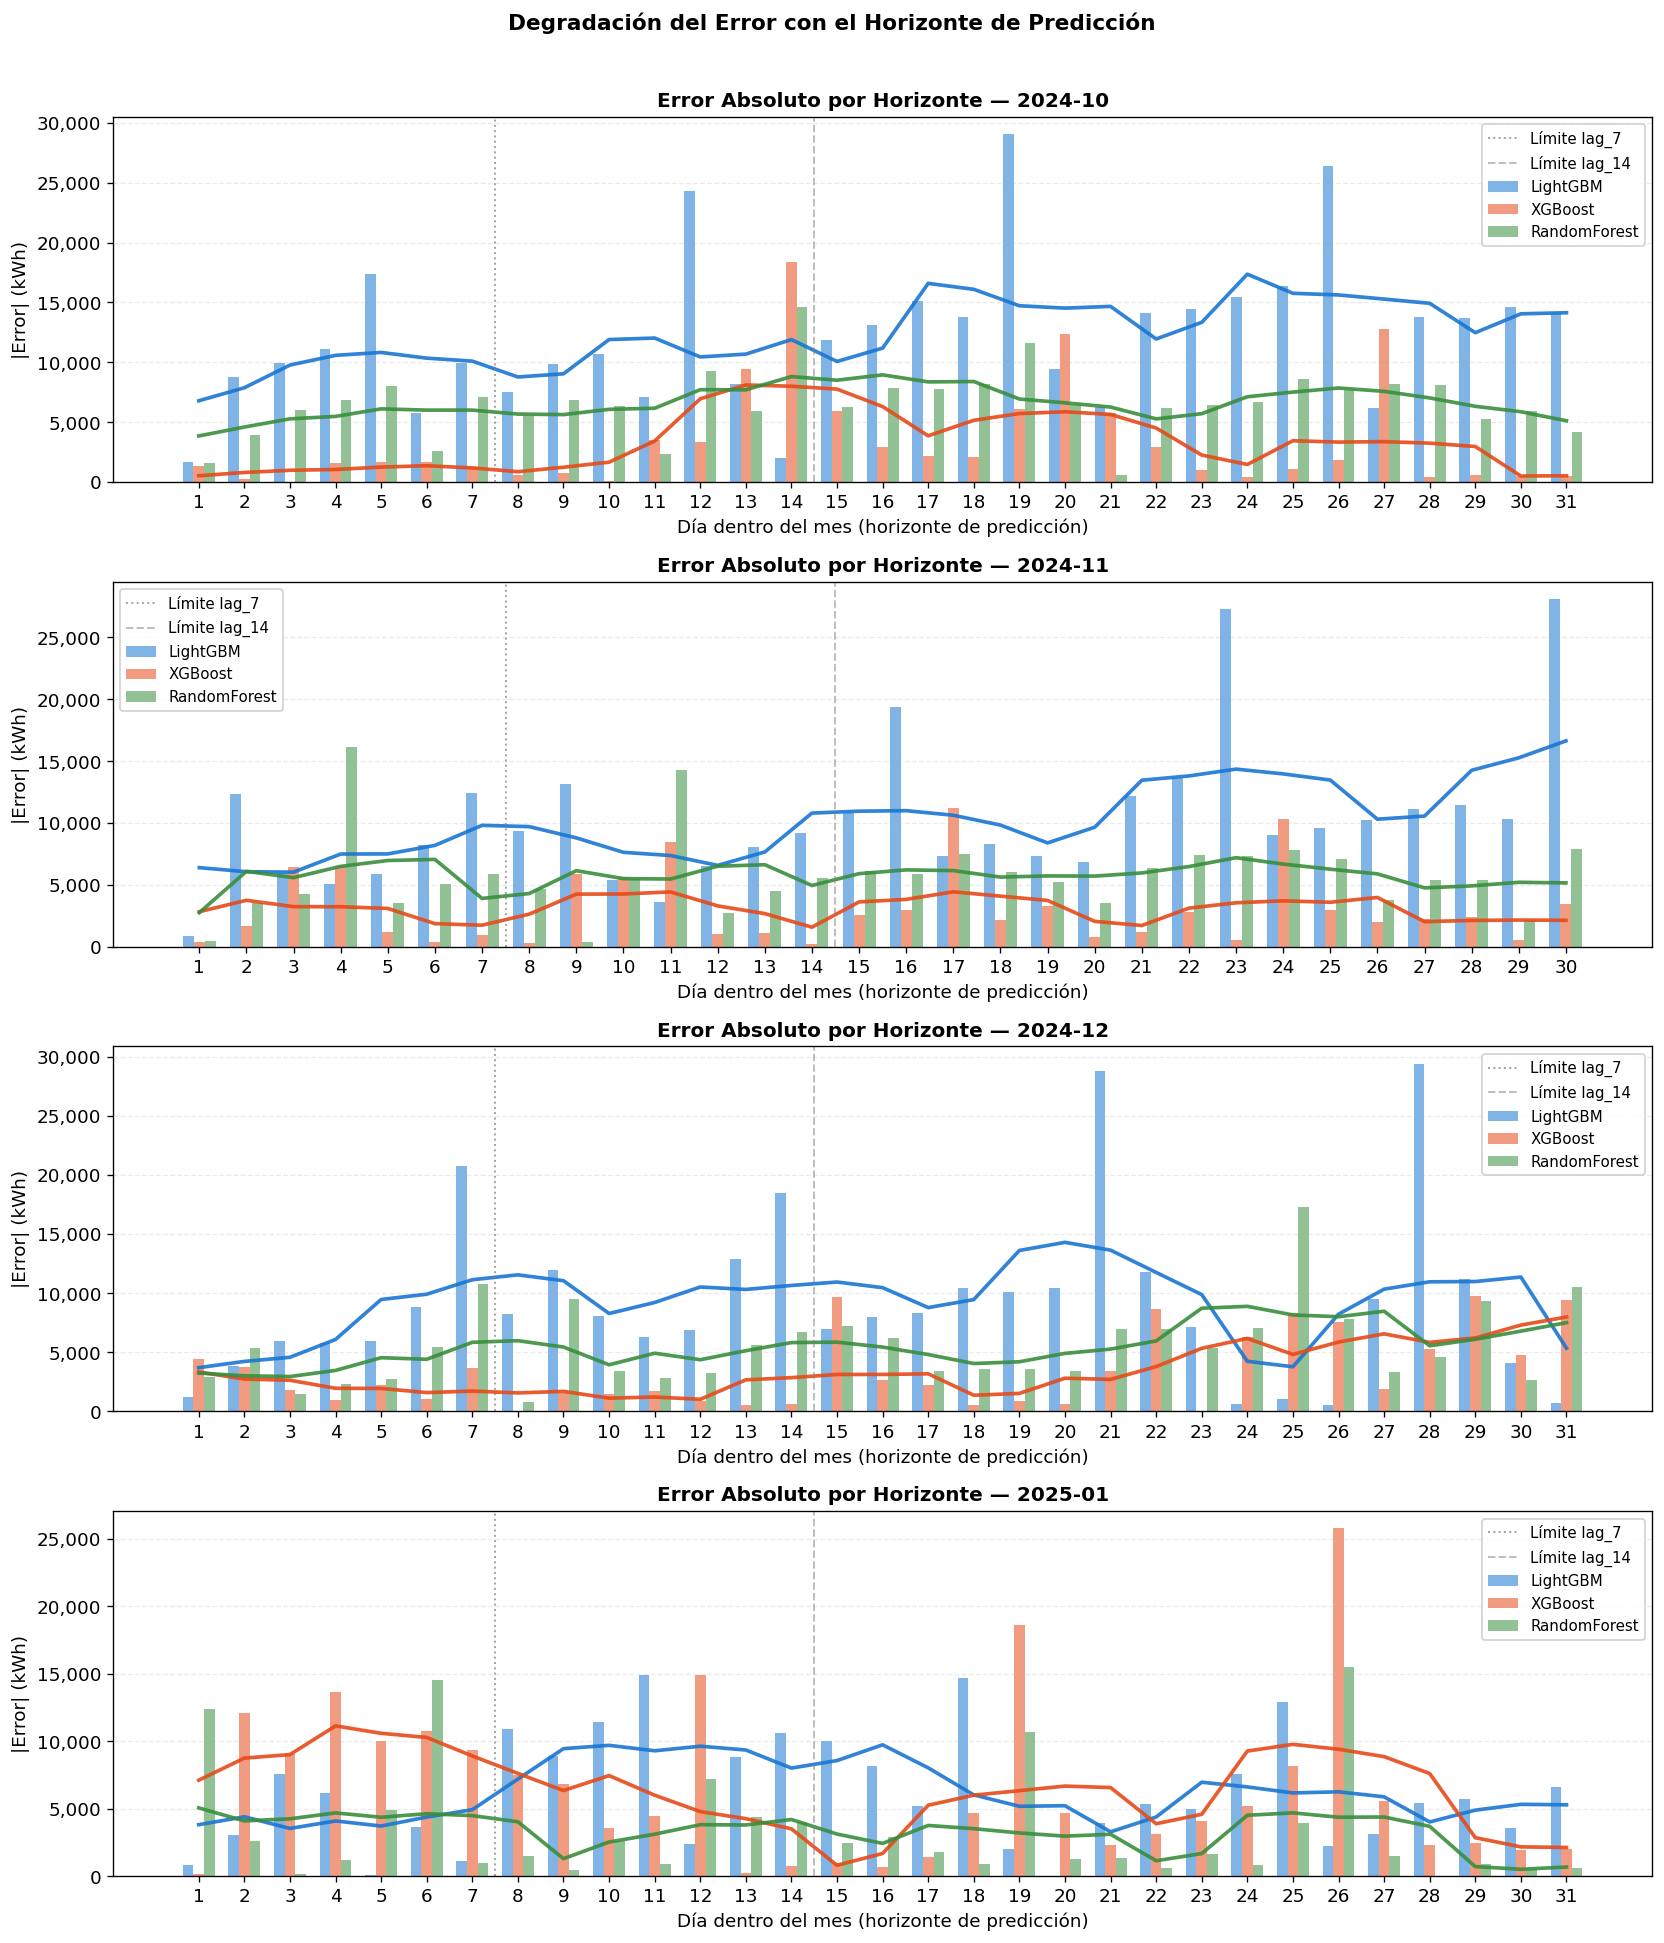

Guardado: error_horizonte.png


In [ ]:
n_mes = len(TEST_MONTHS)
fig, axes = plt.subplots(n_mes, 1, figsize=(14, 4.0 * n_mes), sharex=False)
if n_mes == 1:
    axes = [axes]

BAR_W   = 0.7 / max(len(MODELS), 1)
offsets = {m: (i - (len(MODELS)-1)/2) * BAR_W
           for i, m in enumerate(MODELS)}

for ax, mes in zip(axes, TEST_MONTHS):
    res  = results[mes]
    real = res[MODELS[0]]['real']
    dias = np.arange(1, len(real) + 1)

    # Barras de error absoluto por modelo
    for model_name in MODELS:
        preds  = res[model_name]['preds']
        errors = np.abs(real - preds)
        ax.bar(dias + offsets[model_name], errors,
               width=BAR_W, color=COLORS[model_name],
               alpha=0.55, label=model_name)

    # Línea de tendencia (media móvil 5 días) por modelo
    for model_name in MODELS:
        preds  = res[model_name]['preds']
        errors = np.abs(real - preds)
        win    = min(5, len(errors))
        trend  = pd.Series(errors).rolling(win, center=True, min_periods=1).mean()
        ax.plot(dias, trend, '-', lw=2.2, color=COLORS[model_name], alpha=0.9)

    # Línea vertical donde los lags cortos se vuelven inútiles (~día 7)
    ax.axvline(x=7.5, color='gray', lw=1.2, ls=':', alpha=0.7,
               label='Límite lag_7')
    ax.axvline(x=14.5, color='gray', lw=1.2, ls='--', alpha=0.5,
               label='Límite lag_14')

    ax.set_title(f'Error Absoluto por Horizonte — {mes}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Día dentro del mes (horizonte de predicción)')
    ax.set_ylabel('|Error| (kWh)')
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(True, axis='y', alpha=0.25, linestyle='--')
    ax.set_xticks(dias)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Degradación del Error con el Horizonte de Predicción',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('error_horizonte.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: error_horizonte.png")


## 9. Tabla comparativa de métricas

In [ ]:
# Construir DataFrame de métricas
rows = []
for mes in TEST_MONTHS:
    for model_name in MODELS:
        m = results[mes][model_name]['metrics']
        rows.append({
            'Mes Test' : mes,
            'Modelo'   : model_name,
            'MAE'      : m['MAE'],
            'RMSE'     : m['RMSE'],
            'MAPE (%)' : m['MAPE (%)'],
            'R²'       : m['R²'],
        })

summary_df = pd.DataFrame(rows).set_index(['Mes Test', 'Modelo'])

print("\n" + "="*65)
print("      MÉTRICAS POR MES Y MODELO")
print("="*65)
print(summary_df.to_string())

# Promedio por modelo
avg = summary_df.groupby('Modelo').mean()
print("\n--- Promedio sobre todos los meses ---")
print(avg.round(2).to_string())

# Mejor modelo por métrica
print("\n--- Mejor modelo por métrica (menor error / mayor R²) ---")
for col in ['MAE', 'RMSE', 'MAPE (%)']:
    best = avg[col].idxmin()
    print(f"  {col:<12s}: {best:13s} ({avg.loc[best, col]:.2f})")
best_r2 = avg['R²'].idxmax()
print(f"  {'R²':<12s}: {best_r2:13s} ({avg.loc[best_r2, 'R²']:.4f})")



      MÉTRICAS POR MES Y MODELO
                            MAE      RMSE  MAPE (%)      R²
Mes Test Modelo                                            
2024-10  LightGBM      12324.84  13748.66   16.4334 -0.2264
         XGBoost        3336.42   5442.51    5.8499  0.8078
         RandomForest   6549.66   7088.46    9.3359  0.6740
2024-11  LightGBM      10307.40  11822.80   14.4698  0.2030
         XGBoost        3051.41   4238.08    5.4799  0.8976
         RandomForest   5708.43   6535.36    9.0847  0.7565
2024-12  LightGBM       9173.68  11526.33   13.1707  0.2085
         XGBoost        3436.93   4629.31    6.0036  0.8723
         RandomForest   5565.00   6496.28    8.8784  0.7486
2025-01  LightGBM       6192.29   7416.86    9.3637  0.6148
         XGBoost        6365.94   8635.70   12.1757  0.4777
         RandomForest   3399.02   5371.49    7.1476  0.7979

--- Promedio sobre todos los meses ---
                  MAE      RMSE  MAPE (%)    R²
Modelo                                 

## 10. Heatmap de MAPE (%) — mes × modelo

In [ ]:
mape_pivot = summary_df['MAPE (%)'].unstack(level='Modelo')

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(mape_pivot.values, cmap='RdYlGn_r', aspect='auto',
               vmin=mape_pivot.values.min() * 0.9,
               vmax=mape_pivot.values.max() * 1.1)

ax.set_xticks(range(len(mape_pivot.columns)))
ax.set_yticks(range(len(mape_pivot.index)))
ax.set_xticklabels(mape_pivot.columns, fontsize=12, fontweight='bold')
ax.set_yticklabels(mape_pivot.index, fontsize=11)

mean_val = mape_pivot.values.mean()
for i in range(len(mape_pivot.index)):
    for j in range(len(mape_pivot.columns)):
        val = mape_pivot.values[i, j]
        ax.text(j, i, f'{val:.2f}%',
                ha='center', va='center', fontsize=13, fontweight='bold',
                color='white' if val > mean_val else 'black')

plt.colorbar(im, ax=ax, label='MAPE (%)')
ax.set_title('MAPE (%) por Mes y Modelo', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('heatmap_mape.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: heatmap_mape.png")


## 11. Importancia de features (LightGBM)

Se promedia la importancia (gain) sobre todos los meses de test para tener una visión estable de qué features guían las predicciones.


In [ ]:
if 'LightGBM' in MODELS:
    importances = []
    for mes in TEST_MONTHS:
        model = results[mes]['LightGBM']['model']
        imp   = pd.Series(model.feature_importances_, index=FEATURES_TREE)
        importances.append(imp)

    avg_imp = pd.concat(importances, axis=1).mean(axis=1)
    top25   = avg_imp.nlargest(25).sort_values()

    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(top25.index, top25.values, color='#1976D2', alpha=0.8, edgecolor='white')
    ax.set_xlabel('Importancia promedio (gain)', fontsize=11)
    ax.set_title('Top 25 Features — LightGBM (promedio sobre meses de test)',
                 fontsize=12, fontweight='bold')
    ax.grid(True, axis='x', alpha=0.25, linestyle='--')
    # Anotar valores
    for bar, val in zip(bars, top25.values):
        ax.text(val * 1.005, bar.get_y() + bar.get_height()/2,
                f'{val:,.0f}', va='center', fontsize=8, color='#333')
    plt.tight_layout()
    plt.savefig('feature_importance_lgb.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Guardado: feature_importance_lgb.png")
else:
    print("LightGBM no disponible — omitiendo gráfica de importancia.")


## 12. Error medio por horizonte — todos los meses agregados

Agrupa los errores absolutos de todos los meses de test y los promedia por posición dentro del mes.  
Esto revela si hay un patrón sistemático de degradación en los últimos días.


In [ ]:
# Construir DataFrame de errores diarios agregados
error_records = []
for mes in TEST_MONTHS:
    res  = results[mes]
    real = res[MODELS[0]]['real']
    for model_name in MODELS:
        preds  = res[model_name]['preds']
        errors = np.abs(real - preds)
        for i, (err, val) in enumerate(zip(errors, real)):
            error_records.append({
                'Mes'        : mes,
                'Modelo'     : model_name,
                'Horizonte'  : i + 1,
                'AbsError'   : err,
                'APE'        : err / val * 100 if val != 0 else np.nan,
            })

err_df = pd.DataFrame(error_records)

# Promedio de APE por horizonte y modelo
ape_pivot = err_df.groupby(['Horizonte', 'Modelo'])['APE'].mean().unstack('Modelo')

fig, ax = plt.subplots(figsize=(14, 5))
for model_name in MODELS:
    if model_name in ape_pivot.columns:
        ax.plot(ape_pivot.index, ape_pivot[model_name],
                '-o', ms=5, lw=2, color=COLORS[model_name],
                label=model_name)

ax.axvline(x=7,  color='gray', lw=1.1, ls=':',  alpha=0.7, label='Día 7')
ax.axvline(x=14, color='gray', lw=1.1, ls='--', alpha=0.5, label='Día 14')
ax.set_xlabel('Día dentro del mes (horizonte)', fontsize=11)
ax.set_ylabel('APE promedio (%) — promedio sobre meses', fontsize=11)
ax.set_title('Error Porcentual Absoluto Promedio por Horizonte',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.25, linestyle='--')
ax.set_xticks(ape_pivot.index)
plt.tight_layout()
plt.savefig('ape_por_horizonte.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: ape_por_horizonte.png")


## 13. Exportar resultados

In [ ]:
# Predicciones detalladas
all_preds = []
for mes in TEST_MONTHS:
    for model_name in MODELS:
        r = results[mes][model_name]
        for date, pred, real_v in zip(r['dates'], r['preds'], r['real']):
            all_preds.append({
                'Fecha'     : date.date(),
                'Mes'       : mes,
                'Modelo'    : model_name,
                'Real'      : real_v,
                'Prediccion': round(pred, 2),
                'Error'     : round(real_v - pred, 2),
                'AbsError'  : round(abs(real_v - pred), 2),
                'APE (%)'   : round(abs(real_v - pred) / real_v * 100, 4)
                               if real_v != 0 else None,
            })

preds_df = pd.DataFrame(all_preds)
preds_df.to_csv('predicciones_detalle.csv', index=False)

summary_df.to_csv('metricas_resumen.csv')

print("Archivos exportados:")
print("  predicciones_detalle.csv  — predicción y error por día y modelo")
print("  metricas_resumen.csv      — MAE / RMSE / MAPE / R² por mes y modelo")
print()
print(preds_df.head(10).to_string(index=False))
